# Part 2

In [1]:
# ---- libraries used in Part 2 ----
import os                        # Task A-1
import pandas as pd              # Task A-1, A-12, Task C-13
import geopandas as gpd          # Task A-2 to A-4, Task C-3, C-9, C-14
import numpy as np               # Task A-3, Task B-7, Task B-8
from shapely.geometry import Point, box   # Task A-3, Task C-10, C-11
import matplotlib.pyplot as plt  # Task A-4, A-10, Task B-1, B-5, B-7, B-9, B-11, Task C-4, C-14, C-15
from pyproj import Transformer   # Task A-5, Task C-11
import osmnx as ox               # Task A-6 to A-8, Task B-0, B-2, Task C-11
import networkx as nx            # Task A-9, A-11, Task C-5 to C-8, C-11 to C-13
from libpysal.weights import W   # Task B-6
from esda.moran import Moran     # Task B-6
from pointpats import k          # Task B-7
from shapely.ops import nearest_points  # Task C-3, C-11, C-14
import random                    # Task C-7, C-8, C-11, C-14


# ---- OSMnx settings ----
ox.settings.use_cache = True     # Part 2 to reuse downloaded OSM data
ox.settings.log_console = True   # Part 2 to show OSMnx processing logs

### Task A (spatial networks and planarity):

In [2]:
# =========================
# Task A-1: Load and clean accident data
# =========================

# ---- define accident data files ----
files = [
    "datasets/task02/2009.csv",
    "datasets/task02/2010.csv",
    "datasets/task02/2011.csv",
    "datasets/task02/2012.csv",
    "datasets/task02/2013.csv",
    "datasets/task02/2014.csv",
    "datasets/task02/2015.csv",
    "datasets/task02/2016.csv",
]

dfs = []

# ---- load and preprocess each dataset ----
for f in files:
    df = pd.read_csv(f, encoding="latin1")

    # ---- extract year from filename ----
    filename = os.path.basename(f)
    df["year"] = int(filename[:4])

    # ---- standardise coordinate column names ----
    df = df.rename(columns={
        "Grid Ref: Easting": "Easting",
        "Grid Ref: Northing": "Northing",
    })

    # ---- remove unnecessary columns ----
    drop_cols = [c for c in df.columns if "Unnamed" in c or c == "Expr1"]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    # ---- keep relevant columns ----
    needed_cols = [
        "Reference Number", "Easting", "Northing",
        "Number of Vehicles", "Accident Date", "Time (24hr)",
        "1st Road Class", "Road Surface", "Lighting Conditions",
        "Weather Conditions", "Casualty Class", "Casualty Severity",
        "Sex of Casualty", "Age of Casualty", "Type of Vehicle", "year",
    ]

    df = df[[c for c in needed_cols if c in df.columns]]
    dfs.append(df)

# ---- combine all years ----
accidents_raw = pd.concat(dfs, ignore_index=True)

# ---- remove duplicates and invalid records ----
accidents_unique = (
    accidents_raw
    .dropna(subset=["Reference Number", "Easting", "Northing"])
    .sort_values(["year", "Reference Number"])
    .drop_duplicates(subset=["year", "Reference Number"])
    .copy()
)

# ---- check final dataset size ----
print("Unique accidents:", len(accidents_unique))

Unique accidents: 15637


In [3]:
# =========================
# Task A-2: Convert to GeoDataFrame
# =========================

# ---- create GeoDataFrame from accident data ----
acc_gdf = gpd.GeoDataFrame(
    accidents_unique,
    geometry=gpd.points_from_xy(
        accidents_unique["Easting"],
        accidents_unique["Northing"]
    ),
    crs="EPSG:27700"
)

# ---- extract spatial bounds of the dataset ----
minx, miny, maxx, maxy = acc_gdf.total_bounds
print("Bounds:", minx, miny, maxx, maxy)

Bounds: 414118.0 423127.0 447413.0 449895.0


In [4]:
# =========================
# Task A-3: Find the 1km x 1km area with many accidents
# =========================

# ---- define grid size ----
cell_size = 1000  # 1000 m = 1 km

# ---- create grid coordinates ----
x_starts = np.arange(
    np.floor(minx / cell_size) * cell_size,
    np.ceil(maxx / cell_size) * cell_size,
    cell_size
)

y_starts = np.arange(
    np.floor(miny / cell_size) * cell_size,
    np.ceil(maxy / cell_size) * cell_size,
    cell_size
)

records = []

# ---- count accidents in each grid cell ----
for x0 in x_starts:
    for y0 in y_starts:
        square = box(x0, y0, x0 + cell_size, y0 + cell_size)

        # ---- count accidents including boundary points ----
        count = acc_gdf.intersects(square).sum()

        records.append({
            "xmin": x0,
            "ymin": y0,
            "xmax": x0 + cell_size,
            "ymax": y0 + cell_size,
            "accident_count": int(count),
            "geometry": square
        })

# ---- create grid GeoDataFrame and inspect top cells ----
grid_gdf = gpd.GeoDataFrame(records, crs="EPSG:27700")

top_cells = grid_gdf.sort_values("accident_count", ascending=False).head(10)
display(top_cells[["xmin", "ymin", "xmax", "ymax", "accident_count"]])

# ---- select the cell with the highest accident count ----
best_cell = top_cells.iloc[0]

xmin, ymin = best_cell["xmin"], best_cell["ymin"]
xmax, ymax = best_cell["xmax"], best_cell["ymax"]

chosen_polygon = box(xmin, ymin, xmax, ymax)
acc_area = acc_gdf[acc_gdf.intersects(chosen_polygon)].copy()

# ---- report the selected area ----
print("Chosen area accidents:", len(acc_area))
print("Chosen area (EPSG:27700):")
print("xmin =", xmin)
print("ymin =", ymin)
print("xmax =", xmax)
print("ymax =", ymax)

,xmin,ymin,xmax,ymax,accident_count
442,430000.0,433000.0,431000.0,434000.0,675
471,431000.0,435000.0,432000.0,436000.0,457
415,429000.0,433000.0,430000.0,434000.0,429
443,430000.0,434000.0,431000.0,435000.0,330
390,428000.0,435000.0,429000.0,436000.0,252
389,428000.0,434000.0,429000.0,435000.0,235
470,431000.0,434000.0,432000.0,435000.0,232
444,430000.0,435000.0,431000.0,436000.0,229
364,427000.0,436000.0,428000.0,437000.0,211
416,429000.0,434000.0,430000.0,435000.0,198


Chosen area accidents: 675
Chosen area (EPSG:27700):
xmin = 430000.0
ymin = 433000.0
xmax = 431000.0
ymax = 434000.0


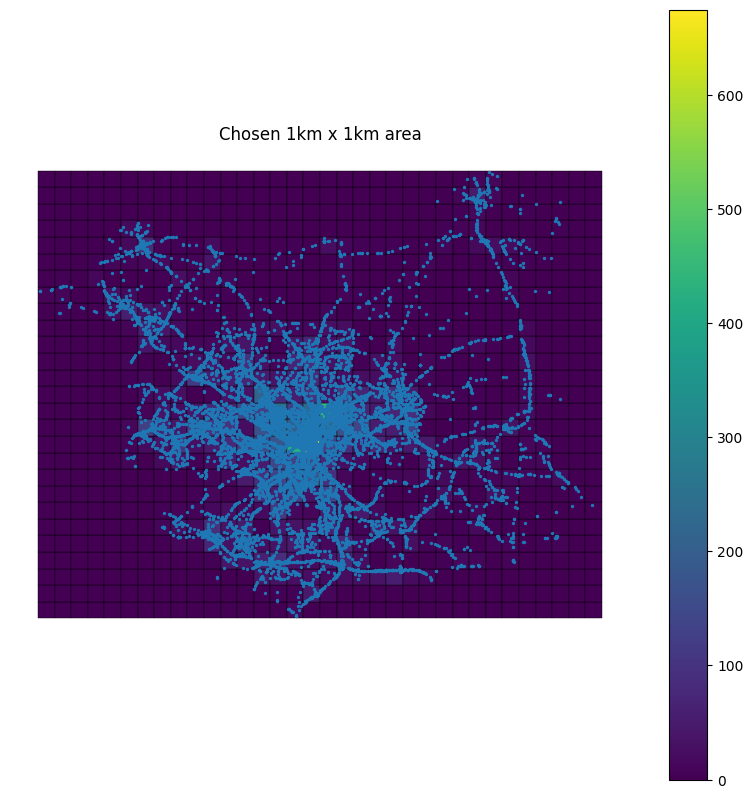

In [5]:
# =========================
# Task A-4: Visual check of chosen area
# =========================

# ---- plot accident density grid ----
ax = grid_gdf.plot(
    column="accident_count",
    figsize=(10, 10),
    legend=True,
    edgecolor="black",
    linewidth=0.3
)

# ---- overlay accident points and selected area ----
acc_gdf.plot(ax=ax, markersize=2)
gpd.GeoSeries([chosen_polygon], crs="EPSG:27700").boundary.plot(ax=ax, linewidth=2)

# ---- format and display plot ----
ax.set_title("Chosen 1km x 1km area")
ax.set_axis_off()
plt.show()

In [6]:
# =========================
# Task A-5: Convert bounding box to latitude/longitude for OSMnx
# =========================

# ---- create coordinate transformer (EPSG:27700 → EPSG:4326) ----
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326", always_xy=True)

# ---- convert bounding box coordinates ----
west, south = transformer.transform(xmin, ymin)
east, north = transformer.transform(xmax, ymax)

# ---- display converted coordinates ----
print("Chosen area (EPSG:4326):")
print("west  =", west)
print("south =", south)
print("east  =", east)
print("north =", north)

Chosen area (EPSG:4326):
west  = -1.5460861672377075
south = 53.792453860486106
east  = -1.5308066430621496
north = 53.80138313507575


In [7]:
# =========================
# Task A-6: Download the driving road network
# =========================

# ---- define bounding box for OSMnx ----
# OSMnx expects bbox in the order: (left, bottom, right, top)
bbox = (west, south, east, north)

# ---- download driving road network ----
G = ox.graph_from_bbox(
    bbox=bbox,
    network_type="drive",
    simplify=True
)

# ---- inspect basic graph information ----
print(G)
print("Number of nodes:", len(G.nodes))
print("Number of edges:", len(G.edges))

MultiDiGraph with 224 nodes and 369 edges
Number of nodes: 224
Number of edges: 369


In [8]:
# =========================
# Task A-7: Basic road network statistics
# =========================

# ---- compute basic road network statistics ----
stats = ox.basic_stats(G)

# ---- display statistics ----
print(stats)

{'n': 224, 'm': 369, 'k_avg': 3.294642857142857, 'edge_length_total': 20305.317635275776, 'edge_length_avg': 55.02796107120807, 'streets_per_node_avg': 2.84375, 'streets_per_node_counts': {0: 0, 1: 30, 2: 12, 3: 146, 4: 35, 5: 1}, 'streets_per_node_proportions': {0: 0.0, 1: 0.13392857142857142, 2: 0.05357142857142857, 3: 0.6517857142857143, 4: 0.15625, 5: 0.004464285714285714}, 'intersection_count': 194, 'street_length_total': 16478.96125979236, 'street_segment_count': 297, 'street_length_avg': 55.48471804643892, 'circuity_avg': 1.0314443645068285, 'self_loop_proportion': 0.0}


In [9]:
# =========================
# Task A-8: Extract the required metrics
# =========================

# ---- extract metrics from basic statistics ----
avg_street_length = stats.get("street_length_avg", None)
avg_edge_length = stats.get("edge_length_avg", None)

node_density = stats.get("node_density_km", None)
intersection_density = stats.get("intersection_density_km", None)
edge_density = stats.get("edge_density_km", None)

intersection_count = stats.get("intersection_count", None)
circuity_avg = stats.get("circuity_avg", None)

# ---- handle missing values (manual calculation) ----
# The chosen study area is 1 km x 1 km = 1 km²
area_km2 = 1.0

if node_density is None:
    node_density = len(G.nodes) / area_km2

if intersection_density is None and intersection_count is not None:
    intersection_density = intersection_count / area_km2

if edge_density is None:
    edge_density = len(G.edges) / area_km2

# ---- display extracted metrics ----
print("Average street length:", avg_street_length)
print("Average edge length:", avg_edge_length)
print("Node density:", node_density)
print("Intersection density:", intersection_density)
print("Edge density:", edge_density)
print("Intersection count:", intersection_count)
print("Average circuity:", circuity_avg)

Average street length: 55.48471804643892
Average edge length: 55.02796107120807
Node density: 224.0
Intersection density: 194.0
Edge density: 369.0
Intersection count: 194
Average circuity: 1.0314443645068285


In [10]:
# =========================
# Task A-9: Spatial diameter (distance-based)
# =========================

# ---- convert to undirected simple graph ----
# Keep the minimum edge length when multiple edges exist
G_u = nx.Graph()

for u, v, data in G.edges(data=True):
    length = data.get("length", 1.0)

    if G_u.has_edge(u, v):
        if length < G_u[u][v]["length"]:
            G_u[u][v]["length"] = length
    else:
        G_u.add_edge(u, v, length=length)

# ---- extract the largest connected component ----
largest_cc_nodes = max(nx.connected_components(G_u), key=len)
G_lcc = G_u.subgraph(largest_cc_nodes).copy()

# ---- compute weighted shortest-path distances ----
all_lengths = dict(nx.all_pairs_dijkstra_path_length(G_lcc, weight="length"))

# ---- find the spatial diameter ----
spatial_diameter = 0
for source, targets in all_lengths.items():
    local_max = max(targets.values())
    if local_max > spatial_diameter:
        spatial_diameter = local_max

# ---- display spatial diameter ----
print("Spatial diameter (metres):", spatial_diameter)
print("Spatial diameter (km):", spatial_diameter / 1000)

Spatial diameter (metres): 2374.837769144526
Spatial diameter (km): 2.374837769144526


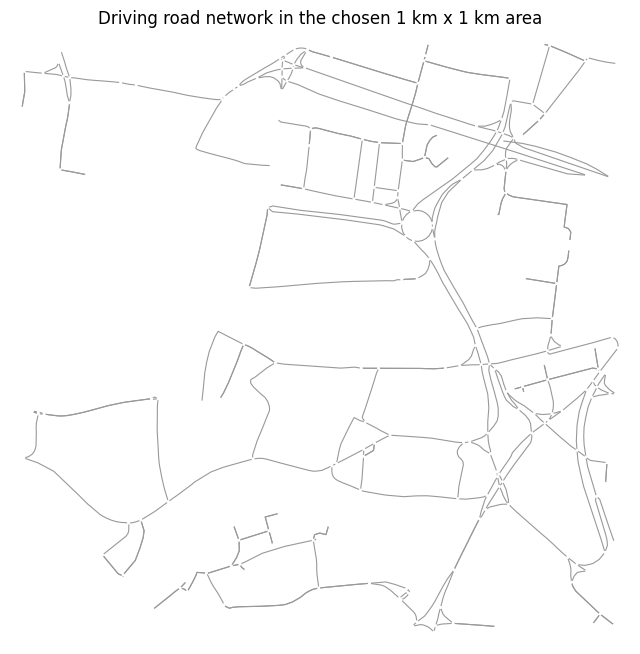

In [11]:
# =========================
# Task A-10: Plot the road network
# =========================

# ---- plot road network ----
fig, ax = ox.plot_graph(
    G,
    node_size=5,
    edge_linewidth=0.8,
    bgcolor="white",
    show=False,
    close=False
)

# ---- format and display plot ----
ax.set_title("Driving road network in the chosen 1 km x 1 km area")
plt.show()

In [12]:
# =========================
# Task A-11: Planarity check
# =========================

# ---- convert to simple undirected graph ----
G_planar = nx.Graph()

for u, v, data in G.edges(data=True):
    if u != v:
        length = data.get("length", 1.0)

        if G_planar.has_edge(u, v):
            if length < G_planar[u][v]["length"]:
                G_planar[u][v]["length"] = length
        else:
            G_planar.add_edge(u, v, length=length)

# ---- extract largest connected component ----
largest_cc_planar = max(nx.connected_components(G_planar), key=len)
G_planar_lcc = G_planar.subgraph(largest_cc_planar).copy()

# ---- perform planarity test ----
is_planar, embedding = nx.check_planarity(G_planar_lcc)

# ---- display result ----
print("Planar according to graph-theoretic check:", is_planar)

Planar according to graph-theoretic check: True


In [13]:
# =========================
# Task A-12: Summary
# =========================

# ---- create summary table for Task A ----
summary_taskA = pd.DataFrame([
    {
        "Chosen area accidents": len(acc_area),
        "West": west,
        "South": south,
        "East": east,
        "North": north,
        "Number of nodes": len(G.nodes),
        "Number of edges": len(G.edges),
        "Average street length": avg_street_length,
        "Average edge length": avg_edge_length,
        "Node density": node_density,
        "Intersection density": intersection_density,
        "Edge density": edge_density,
        "Intersection count": intersection_count,
        "Average circuity": circuity_avg,
        "Spatial diameter (m)": spatial_diameter,
        "Spatial diameter (km)": spatial_diameter / 1000,
        "Graph-theoretic planar": is_planar,
    }
])

# ---- display summary ----
display(summary_taskA)

,Chosen area accidents,West,South,East,North,Number of nodes,Number of edges,Average street length,Average edge length,Node density,Intersection density,Edge density,Intersection count,Average circuity,Spatial diameter (m),Spatial diameter (km),Graph-theoretic planar
0,675,-1.546086,53.792454,-1.530807,53.801383,224,369,55.484718,55.027961,224.0,194.0,369.0,194,1.031444,2374.837769,2.374838,True


### Task B (road accidents):

In [14]:
# =========================
# Task B-1: Prepare road network GeoDataFrames
# =========================

# ---- project graph and convert to GeoDataFrames ----
G_proj = ox.project_graph(G, to_crs="EPSG:27700")
nodes, edges = ox.graph_to_gdfs(G_proj)

# ---- inspect GeoDataFrame sizes ----
print(nodes.shape, edges.shape)

(224, 6) (369, 15)


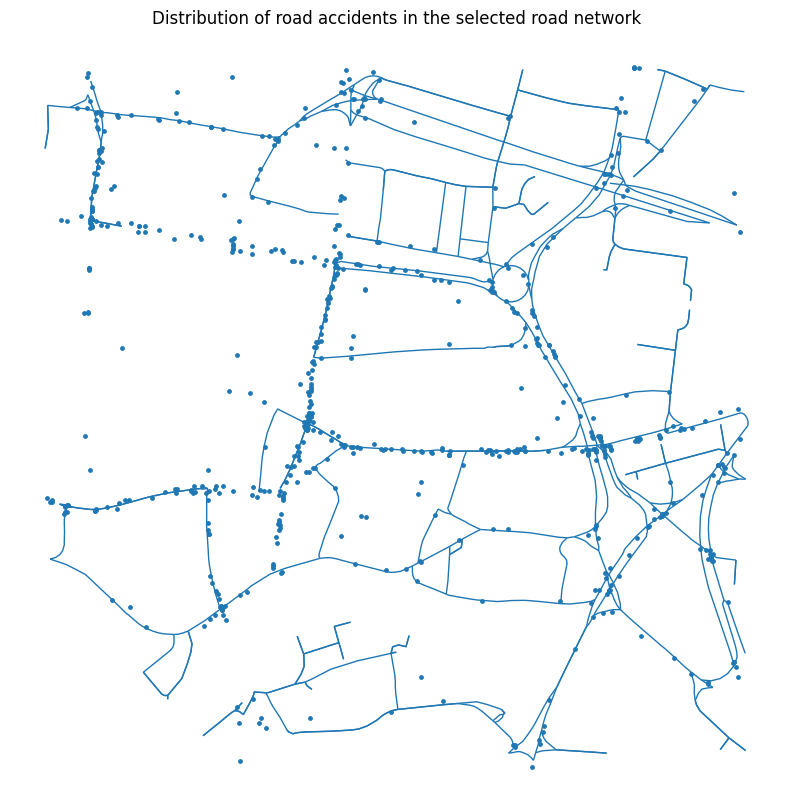

In [15]:
# =========================
# Task B-2: Plot accident distribution on the road network
# =========================

# ---- plot road network ----
ax = edges.plot(figsize=(10, 10), linewidth=1)

# ---- overlay accident points ----
acc_area.plot(ax=ax, markersize=6)

# ---- format and display plot ----
ax.set_title("Distribution of road accidents in the selected road network")
ax.set_axis_off()
plt.show()

In [16]:
# =========================
# Task B-3: Assign accidents to nearest road segments
# =========================

# ---- find nearest road segment for each accident ----
nearest_edges = ox.distance.nearest_edges(
    G_proj,
    X=acc_area.geometry.x.values,
    Y=acc_area.geometry.y.values
)

# ---- store edge identifiers in accident data ----
acc_area = acc_area.copy()
acc_area["edge_id"] = list(nearest_edges)

In [17]:
# =========================
# Task B-4: Aggregate accidents per road segment
# =========================

# ---- count accidents per road segment ----
edge_acc_counts = (
    acc_area.groupby("edge_id")
    .size()
    .reset_index(name="accident_count")
)

In [18]:
# =========================
# Task B-5: Merge accident counts with road network
# =========================

# ---- prepare edge identifiers ----
edges_plot = edges.reset_index().copy()
edges_plot["edge_id"] = list(zip(edges_plot["u"], edges_plot["v"], edges_plot["key"]))

# ---- merge accident counts and fill missing values ----
edges_plot = edges_plot.merge(edge_acc_counts, on="edge_id", how="left")
edges_plot["accident_count"] = edges_plot["accident_count"].fillna(0)

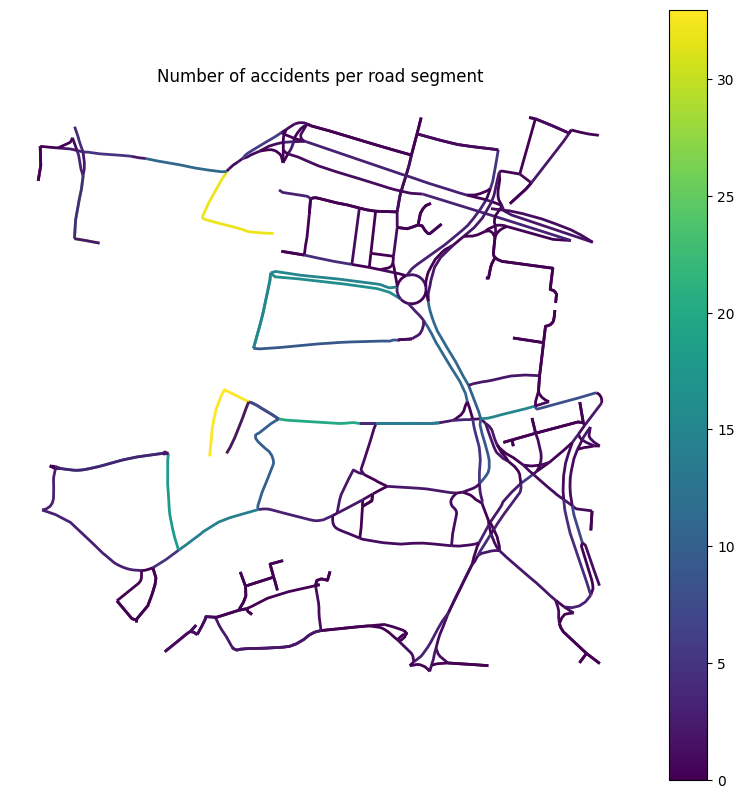

In [19]:
# =========================
# Task B-6: Visualise accident counts per road segment
# =========================

# ---- plot road segments coloured by accident count ----
ax = edges_plot.plot(
    column="accident_count",
    figsize=(10, 10),
    linewidth=2,
    legend=True
)

# ---- format and display plot ----
ax.set_title("Number of accidents per road segment")
ax.set_axis_off()
plt.show()

In [20]:
# =========================
# Task B-7: Compute Moran’s I using road-segment adjacency
# =========================

# ---- prepare edge data for adjacency calculation ----
gdf = edges_plot.copy().reset_index(drop=True)

# ---- map graph nodes to incident road segments ----
node_to_edge_indices = {}

for idx, row in gdf.iterrows():
    u = row["u"]
    v = row["v"]

    node_to_edge_indices.setdefault(u, set()).add(idx)
    node_to_edge_indices.setdefault(v, set()).add(idx)

# ---- build road-segment adjacency based on shared endpoints ----
neighbors = {i: set() for i in gdf.index}

for idx, row in gdf.iterrows():
    u = row["u"]
    v = row["v"]

    adjacent_edges = node_to_edge_indices[u].union(node_to_edge_indices[v])
    adjacent_edges.discard(idx)
    neighbors[idx] = adjacent_edges

# ---- create spatial weights and compute Moran's I ----
neighbors = {k: list(v) for k, v in neighbors.items()}
w = W(neighbors)
w.transform = "r"

moran = Moran(gdf["accident_count"].values, w)

# ---- display Moran's I results ----
print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.3674885436263333
p-value: 0.001


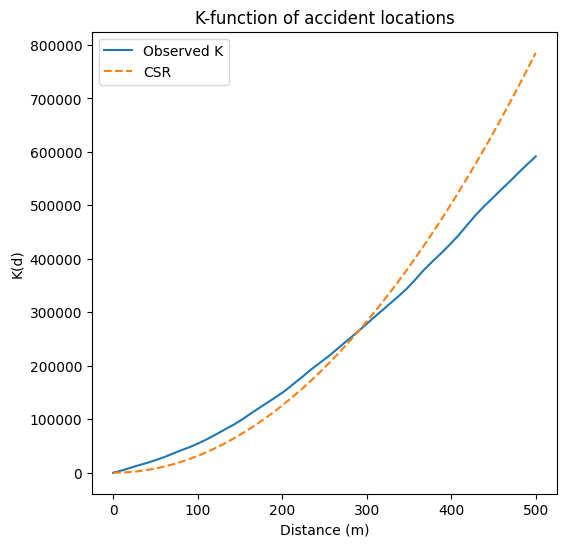

In [21]:
# =========================
# Task B-8: Compute K-function for accident locations
# =========================

from pointpats import k

# ---- prepare point data and distance range ----
points = np.array([(geom.x, geom.y) for geom in acc_area.geometry])
distances = np.linspace(0, 500, 50)

# ---- compute observed and theoretical K-function ----
support, observed_k = k(points, distances)
theoretical_k = np.pi * support**2

# ---- plot K-function results ----
plt.figure(figsize=(6, 6))
plt.plot(support, observed_k, label="Observed K")
plt.plot(support, theoretical_k, linestyle="--", label="CSR")

plt.xlabel("Distance (m)")
plt.ylabel("K(d)")
plt.title("K-function of accident locations")
plt.legend()
plt.show()

In [22]:
# =========================
# Task B-9: Compute accident position relative to nearest intersection
# =========================

# ---- prepare accident and edge data ----
acc_b3 = acc_area.copy()
edges_b3 = edges.reset_index().copy()
edges_b3["edge_id"] = list(zip(edges_b3["u"], edges_b3["v"], edges_b3["key"]))

# ---- assign nearest edge to each accident ----
nearest_edges_b3 = ox.distance.nearest_edges(
    G_proj,
    X=acc_b3.geometry.x.values,
    Y=acc_b3.geometry.y.values
)

acc_b3["edge_id"] = list(nearest_edges_b3)

# ---- create lookup tables for edge geometry and length ----
edge_geom_dict = dict(zip(edges_b3["edge_id"], edges_b3["geometry"]))
edge_len_dict = dict(zip(edges_b3["edge_id"], edges_b3["length"]))

# ---- identify intersections using node degree ----
G_intersection = nx.Graph(G_proj)
node_degree = dict(G_intersection.degree())

fraction_from_nearest_intersection = []

# ---- compute relative accident position along each road segment ----
for _, row in acc_b3.iterrows():
    pt = row.geometry
    eid = row["edge_id"]

    u, v, k = eid
    line = edge_geom_dict[eid]
    line_len = edge_len_dict[eid]

    d = line.project(pt)

    u_is_intersection = node_degree.get(u, 0) >= 3
    v_is_intersection = node_degree.get(v, 0) >= 3

    distances_to_intersections = []

    if u_is_intersection:
        distances_to_intersections.append(d)

    if v_is_intersection:
        distances_to_intersections.append(line_len - d)

    if len(distances_to_intersections) > 0 and line_len > 0:
        nearest_intersection_dist = min(distances_to_intersections)
        frac_nearest = nearest_intersection_dist / line_len
    else:
        frac_nearest = np.nan

    fraction_from_nearest_intersection.append(frac_nearest)

# ---- store relative accident positions ----
acc_b3["fraction_from_nearest_intersection"] = fraction_from_nearest_intersection

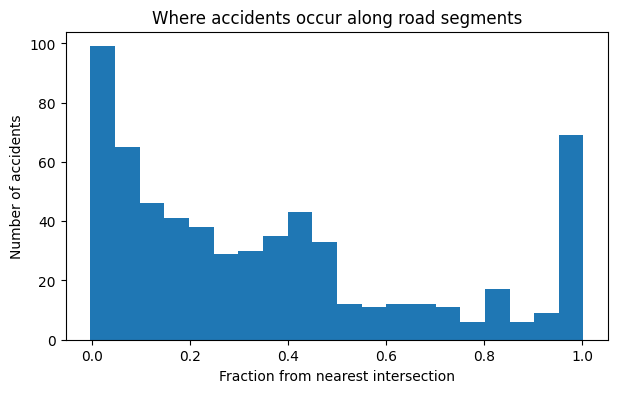

In [23]:
# =========================
# Task B-10: Visualise distribution of accident positions
# =========================

# ---- plot distribution of accident positions ----
plt.figure(figsize=(7, 4))
plt.hist(acc_b3["fraction_from_nearest_intersection"].dropna(), bins=20)

# ---- format and display plot ----
plt.xlabel("Fraction from nearest intersection")
plt.ylabel("Number of accidents")
plt.title("Where accidents occur along road segments")
plt.show()

In [24]:
# =========================
# Task B-11: Summary statistics of accident positions
# =========================

# ---- prepare valid accident position values ----
vals = acc_b3["fraction_from_nearest_intersection"].dropna()

# ---- compute and display summary statistics ----
print("Mean:", vals.mean())
print("Median:", vals.median())
print("25th percentile:", vals.quantile(0.25))
print("75th percentile:", vals.quantile(0.75))

Mean: 0.3685406616339698
Median: 0.28831969975752914
25th percentile: 0.09242389099238804
75th percentile: 0.5394326853811132


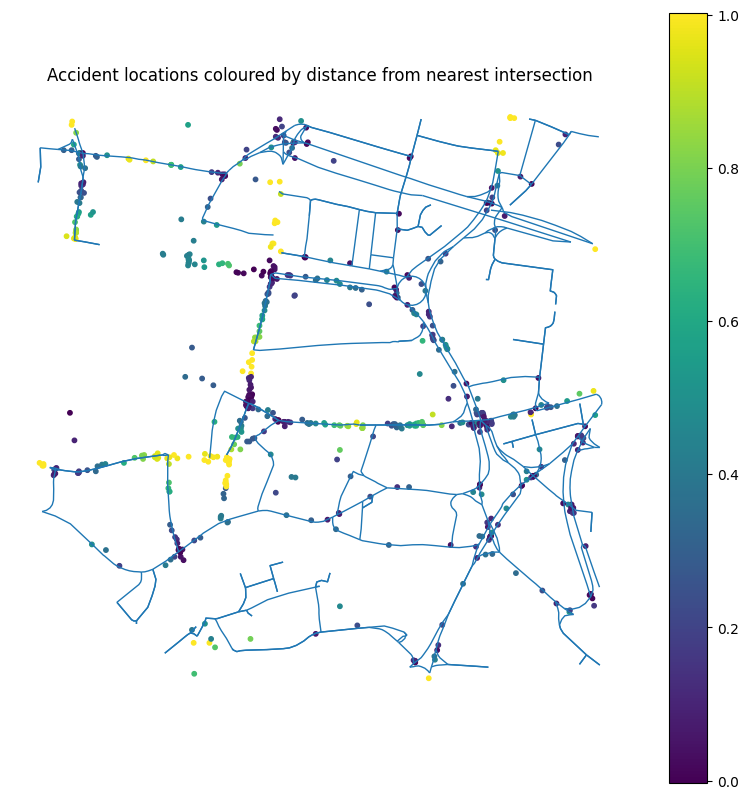

In [25]:
# =========================
# Task B-12: Spatial visualisation of accident positions
# =========================

# ---- plot road network ----
ax = edges.plot(figsize=(10, 10), linewidth=1)

# ---- overlay accident points coloured by relative position ----
acc_b3.plot(
    ax=ax,
    column="fraction_from_nearest_intersection",
    markersize=10,
    legend=True
)

# ---- format and display plot ----
ax.set_title("Accident locations coloured by distance from nearest intersection")
ax.set_axis_off()
plt.show()

### Task C (Voronoi diagrams):

In [26]:
# =========================
# Task C-1: Prepare nodes for Voronoi analysis
# =========================

# ---- prepare node data for Voronoi analysis ----
nodes_c = nodes.copy()

In [27]:
# =========================
# Task C-2: Split the study area into four zones for seed selection
# =========================

# ---- compute centre of the study area ----
mid_x = (xmin + xmax) / 2
mid_y = (ymin + ymax) / 2

# ---- split nodes into four spatial zones ----
q1 = nodes_c[(nodes_c.geometry.x <= mid_x) & (nodes_c.geometry.y >  mid_y)].copy()
q2 = nodes_c[(nodes_c.geometry.x >  mid_x) & (nodes_c.geometry.y >  mid_y)].copy()
q3 = nodes_c[(nodes_c.geometry.x <= mid_x) & (nodes_c.geometry.y <= mid_y)].copy()
q4 = nodes_c[(nodes_c.geometry.x >  mid_x) & (nodes_c.geometry.y <= mid_y)].copy()

# ---- check number of nodes in each zone ----
print(len(q1), len(q2), len(q3), len(q4))

38 67 33 86


In [28]:
# =========================
# Task C-3: Select seed points far from accidents
# =========================

# ---- compute distance to nearest accident ----
acc_union = acc_area.geometry.union_all()

def distance_to_nearest_accident(node_geom):
    nearest_geom = nearest_points(node_geom, acc_union)[1]
    return node_geom.distance(nearest_geom)

# ---- assign distance values to each zone ----
for q in [q1, q2, q3, q4]:
    q["dist_to_accident"] = q.geometry.apply(distance_to_nearest_accident)

# ---- select seed nodes with maximum distance ----
seed1 = q1.sort_values("dist_to_accident", ascending=False).iloc[0]
seed2 = q2.sort_values("dist_to_accident", ascending=False).iloc[0]
seed3 = q3.sort_values("dist_to_accident", ascending=False).iloc[0]
seed4 = q4.sort_values("dist_to_accident", ascending=False).iloc[0]

seed_nodes = gpd.GeoDataFrame(
    [seed1, seed2, seed3, seed4],
    crs=nodes_c.crs
)

seed_ids = list(seed_nodes.index)

# ---- display selected seed nodes ----
display(seed_nodes)

,y,x,street_count,highway,junction,geometry,dist_to_accident
26298479,433882.698714,429999.523003,2,NaN,NaN,POINT (429999.523 433882.699),73.154594
5506378742,433652.970253,430918.271637,1,NaN,NaN,POINT (430918.272 433652.97),121.547560
317020310,433178.268733,430418.250727,3,NaN,NaN,POINT (430418.251 433178.269),114.926948
249203218,433024.490150,430998.171882,1,NaN,NaN,POINT (430998.172 433024.49),105.999036


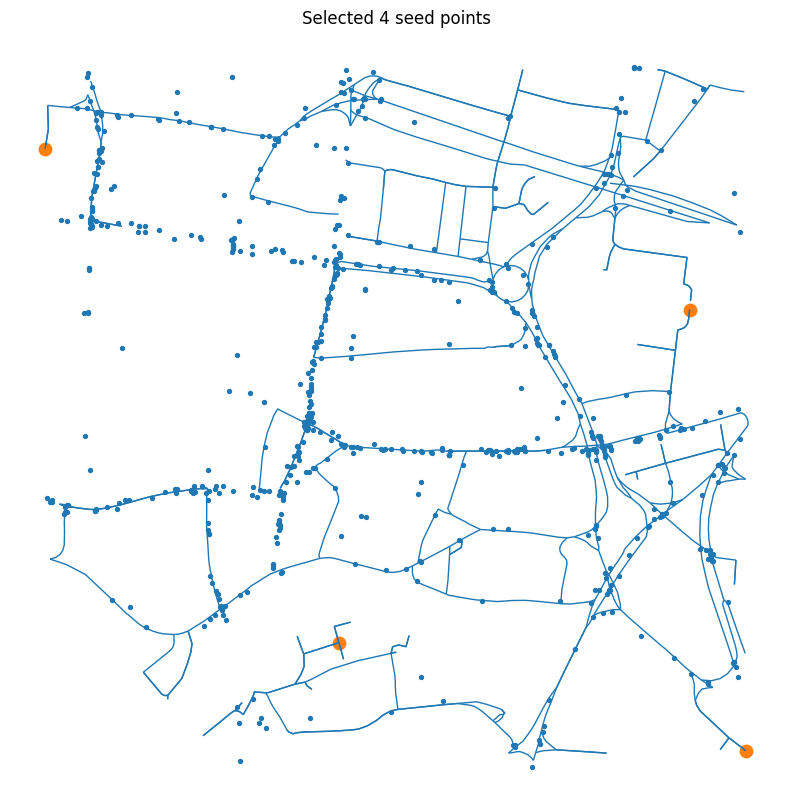

In [29]:
# =========================
# Task C-4: Plot seed points
# =========================

# ---- plot road network ----
ax = edges.plot(figsize=(10, 10), linewidth=1)

# ---- overlay accidents and seed points ----
acc_area.plot(ax=ax, markersize=8)
seed_nodes.plot(ax=ax, markersize=80)

# ---- format and display plot ----
ax.set_title("Selected 4 seed points")
ax.set_axis_off()
plt.show()

In [30]:
# =========================
# Task C-5: Construct node-based Voronoi cells
# =========================

# ---- convert to undirected graph ----
G_ud = nx.Graph(G_proj)

# ---- compute shortest-path distances from each seed ----
distance_cols = {}

for sid in seed_ids:
    dist_dict = nx.single_source_dijkstra_path_length(G_ud, sid, weight="length")
    distance_cols[sid] = pd.Series(dist_dict)

dist_df = pd.DataFrame(distance_cols)

# ---- assign each node to the nearest seed ----
node_cells = nodes.copy()
node_cells["seed_id"] = dist_df.idxmin(axis=1)

In [31]:
# =========================
# Task C-6: Build subgraphs for each cell
# =========================

# ---- initialise dictionary for cell subgraphs ----
cell_graphs = {}

# ---- extract subgraph for each Voronoi cell ----
for sid in seed_ids:
    nodes_in_cell = node_cells[node_cells["seed_id"] == sid].index
    subG = G_ud.subgraph(nodes_in_cell).copy()
    cell_graphs[sid] = subG

In [32]:
# =========================
# Task C-7: Define improved route search functions
# =========================

# ---- compute total path length from node sequence ----
def path_length_from_nodes(G_multi, path_nodes):
    total = 0.0

    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        edge_data = G_multi.get_edge_data(u, v)

        if edge_data is None:
            edge_data = G_multi.get_edge_data(v, u)

        if edge_data is None:
            return None

        if "length" in edge_data:
            total += edge_data["length"]
        else:
            total += min(attr["length"] for attr in edge_data.values())

    return total


# ---- merge multiple path segments into one route ----
def stitch_paths(path_list):
    stitched = []

    for i, p in enumerate(path_list):
        if i == 0:
            stitched.extend(p)
        else:
            stitched.extend(p[1:])

    return stitched


# ---- search for a closed route close to 42 km using waypoint tours ----
def find_closed_route_by_waypoints(
    G_multi,
    target_length=42000,
    tolerance=3000,
    waypoint_options=(4, 5, 6),
    n_trials=4000,
    random_seed=42
):
    rng = random.Random(random_seed)

    # ---- convert to undirected graph and extract largest connected component ----
    G_simple = nx.Graph(G_multi)

    if len(G_simple.nodes) == 0:
        return None

    largest_cc_nodes = max(nx.connected_components(G_simple), key=len)
    H = G_simple.subgraph(largest_cc_nodes).copy()

    node_list = list(H.nodes)
    if len(node_list) < 6:
        return None

    best_route = None
    best_diff = float("inf")

    # ---- try different numbers of waypoints ----
    for k_waypoints in waypoint_options:
        if len(node_list) < k_waypoints:
            continue

        # ---- sample waypoint tours repeatedly ----
        for _ in range(n_trials):
            anchors = rng.sample(node_list, k_waypoints)

            path_segments = []
            feasible = True

            # ---- connect waypoints using shortest paths ----
            for i in range(k_waypoints):
                a = anchors[i]
                b = anchors[(i + 1) % k_waypoints]

                try:
                    seg_path = nx.shortest_path(H, a, b, weight="length")
                except nx.NetworkXNoPath:
                    feasible = False
                    break

                path_segments.append(seg_path)

            if not feasible:
                continue

            # ---- evaluate candidate closed route ----
            closed_route_nodes = stitch_paths(path_segments)
            total_length = path_length_from_nodes(G_multi, closed_route_nodes)

            if total_length is None:
                continue

            diff = abs(total_length - target_length)

            if diff < best_diff:
                best_diff = diff
                best_route = (closed_route_nodes, total_length)

            # ---- return early if route is within tolerance ----
            if diff <= tolerance:
                return (closed_route_nodes, total_length)

    # ---- return the closest route found ----
    return best_route

In [33]:
# =========================
# Task C-8: Find routes (~42 km)
# =========================

# ---- initialise dictionary for route results ----
routes = {}

# ---- search for closed routes in each Voronoi cell ----
for sid in seed_ids:
    G_sub = cell_graphs[sid]

    if len(G_sub.nodes) < 10:
        continue

    route = find_closed_route_by_waypoints(
        G_sub,
        target_length=42000,
        tolerance=3000,
        waypoint_options=(4, 5, 6),
        n_trials=5000,
        random_seed=42
    )

    if route is not None:
        routes[sid] = route

In [34]:
# =========================
# Task C-9: Build route GeoDataFrame for plotting
# =========================

def route_to_gdf(G_multi, route_nodes, crs="EPSG:27700"):
    geoms = []

    for u, v in zip(route_nodes[:-1], route_nodes[1:]):
        edge_data = G_multi.get_edge_data(u, v)

        if edge_data is None:
            edge_data = G_multi.get_edge_data(v, u)

        if edge_data is None:
            continue

        if "geometry" in edge_data:
            geoms.append(edge_data["geometry"])
        else:
            first_attr = list(edge_data.values())[0]
            if "geometry" in first_attr:
                geoms.append(first_attr["geometry"])

    if len(geoms) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=crs)

    return gpd.GeoDataFrame(geometry=geoms, crs=crs)

In [35]:
# =========================
# Task C-10: Check results
# =========================

# ---- display route search results for each seed ----
for sid in seed_ids:
    if sid in routes:
        print(f"Seed {sid}: OK ({routes[sid][1]/1000:.2f} km)")
    else:
        print(f"Seed {sid}: NO ROUTE")

Seed 26298479: OK (3.50 km)
Seed 5506378742: OK (5.59 km)
Seed 317020310: OK (3.07 km)
Seed 249203218: OK (7.28 km)


In [36]:
# =========================
# Task C-11: Define a reusable function for expanded areas
# =========================

def run_expanded_voronoi_and_routes(half_size_m, target_length=42000, tolerance=3000):
    # ---- expanded bbox in EPSG:27700 ----
    center_x = (xmin + xmax) / 2
    center_y = (ymin + ymax) / 2

    xmin_big = center_x - half_size_m
    xmax_big = center_x + half_size_m
    ymin_big = center_y - half_size_m
    ymax_big = center_y + half_size_m

    # ---- convert bbox to EPSG:4326 ----
    west_big, south_big = transformer.transform(xmin_big, ymin_big)
    east_big, north_big = transformer.transform(xmax_big, ymax_big)

    bbox_big = (west_big, south_big, east_big, north_big)

    # ---- get expanded road network ----
    G_big = ox.graph_from_bbox(
        bbox=bbox_big,
        network_type="drive",
        simplify=True
    )

    G_big_proj = ox.project_graph(G_big, to_crs="EPSG:27700")
    nodes_big, edges_big = ox.graph_to_gdfs(G_big_proj)

    # ---- accident subset in expanded area ----
    expanded_polygon = box(xmin_big, ymin_big, xmax_big, ymax_big)
    acc_big = acc_gdf[acc_gdf.intersects(expanded_polygon)].copy()
    acc_union_big = acc_big.geometry.union_all()

    # ---- quadrant split ----
    mid_x_big = (xmin_big + xmax_big) / 2
    mid_y_big = (ymin_big + ymax_big) / 2

    q1_big = nodes_big[(nodes_big.geometry.x <= mid_x_big) & (nodes_big.geometry.y >  mid_y_big)].copy()
    q2_big = nodes_big[(nodes_big.geometry.x >  mid_x_big) & (nodes_big.geometry.y >  mid_y_big)].copy()
    q3_big = nodes_big[(nodes_big.geometry.x <= mid_x_big) & (nodes_big.geometry.y <= mid_y_big)].copy()
    q4_big = nodes_big[(nodes_big.geometry.x >  mid_x_big) & (nodes_big.geometry.y <= mid_y_big)].copy()

    def distance_to_nearest_accident_big(node_geom):
        nearest_geom = nearest_points(node_geom, acc_union_big)[1]
        return node_geom.distance(nearest_geom)

    for q in [q1_big, q2_big, q3_big, q4_big]:
        q["dist_to_accident"] = q.geometry.apply(distance_to_nearest_accident_big)

    seed1_big = q1_big.sort_values("dist_to_accident", ascending=False).iloc[0]
    seed2_big = q2_big.sort_values("dist_to_accident", ascending=False).iloc[0]
    seed3_big = q3_big.sort_values("dist_to_accident", ascending=False).iloc[0]
    seed4_big = q4_big.sort_values("dist_to_accident", ascending=False).iloc[0]

    seed_nodes_big = gpd.GeoDataFrame(
        [seed1_big, seed2_big, seed3_big, seed4_big],
        crs=nodes_big.crs
    )

    seed_ids_big = list(seed_nodes_big.index)

    # ---- node-network Voronoi ----
    G_big_ud = nx.Graph(G_big_proj)

    distance_cols_big = {}
    for sid in seed_ids_big:
        dist_dict = nx.single_source_dijkstra_path_length(G_big_ud, sid, weight="length")
        distance_cols_big[sid] = pd.Series(dist_dict)

    dist_df_big = pd.DataFrame(distance_cols_big)

    node_cells_big = nodes_big.copy()
    node_cells_big["seed_id"] = dist_df_big.idxmin(axis=1)

    # ---- build subgraphs ----
    cell_graphs_big = {}

    for sid in seed_ids_big:
        nodes_in_cell = node_cells_big[node_cells_big["seed_id"] == sid].index
        subG = G_big_ud.subgraph(nodes_in_cell).copy()
        cell_graphs_big[sid] = subG

    # ---- search routes ----
    routes_big = {}

    for sid in seed_ids_big:
        G_sub = cell_graphs_big[sid]

        if len(G_sub.nodes) < 10:
            continue

        route = find_closed_route_by_waypoints(
            G_sub,
            target_length=target_length,
            tolerance=tolerance,
            waypoint_options=(4, 5, 6),
            n_trials=5000,
            random_seed=42
        )

        if route is not None:
            routes_big[sid] = route

    # ---- results table ----
    results_big = []

    for sid in seed_ids_big:
        if sid in routes_big:
            path_nodes, length_m = routes_big[sid]
            results_big.append({
                "seed_id": sid,
                "found_route": True,
                "length_m": length_m,
                "length_km": length_m / 1000,
                "diff_from_42km_m": abs(length_m - 42000)
            })
        else:
            results_big.append({
                "seed_id": sid,
                "found_route": False,
                "length_m": None,
                "length_km": None,
                "diff_from_42km_m": None
            })

    results_big_df = pd.DataFrame(results_big)

    return {
        "half_size_m": half_size_m,
        "bbox": (xmin_big, ymin_big, xmax_big, ymax_big),
        "G_proj": G_big_proj,
        "nodes": nodes_big,
        "edges": edges_big,
        "accidents": acc_big,
        "seed_nodes": seed_nodes_big,
        "seed_ids": seed_ids_big,
        "node_cells": node_cells_big,
        "routes": routes_big,
        "results_df": results_big_df
    }

In [37]:
# =========================
# Task C-12: Try larger areas progressively
# =========================

# ---- define candidate expanded area sizes ----
candidate_half_sizes = [
    2000,  # 4km x 4km
    3000,  # 6km x 6km
    4000,  # 8km x 8km
    5000   # 10km x 10km
]

# ---- run Voronoi and route search for each expanded size ----
expanded_runs = {}

for hs in candidate_half_sizes:
    print(f"\n=== Trying area {(2*hs)/1000:.0f} km x {(2*hs)/1000:.0f} km ===")
    run = run_expanded_voronoi_and_routes(
        half_size_m=hs,
        target_length=42000,
        tolerance=3000
    )
    expanded_runs[hs] = run
    print(run["results_df"])


=== Trying area 4 km x 4 km ===
      seed_id  found_route      length_m  length_km  diff_from_42km_m
0  3987138377         True  17977.667248  17.977667      24022.332752
1  5371319273         True  19689.262058  19.689262      22310.737942
2  3094125481         True  19976.848676  19.976849      22023.151324
3   475367615         True  13996.735903  13.996736      28003.264097

=== Trying area 6 km x 6 km ===
      seed_id  found_route      length_m  length_km  diff_from_42km_m
0   252743703         True  22257.358772  22.257359      19742.641228
1  5371319273         True  23335.199060  23.335199      18664.800940
2   441942844         True  24574.044828  24.574045      17425.955172
3   272096866         True  27281.405546  27.281406      14718.594454

=== Trying area 8 km x 8 km ===
      seed_id  found_route      length_m  length_km  diff_from_42km_m
0   300870331         True  29925.031115  29.925031      12074.968885
1   250735979         True  33437.696134  33.437696       856

In [38]:
# =========================
# Task C-13: Select best expanded solution
# =========================

# ---- initialise selection criteria ----
best_half_size = None
best_num_success = -1
best_min_diff = float("inf")

# ---- compare route results across expanded areas ----
for hs, run in expanded_runs.items():
    df = run["results_df"].copy()
    success_df = df[df["found_route"] == True].copy()

    num_success = len(success_df)

    if num_success > 0:
        min_diff = success_df["diff_from_42km_m"].min()
    else:
        min_diff = float("inf")

    if (num_success > best_num_success) or (num_success == best_num_success and min_diff < best_min_diff):
        best_half_size = hs
        best_num_success = num_success
        best_min_diff = min_diff

# ---- display the best expanded solution ----
best_run = expanded_runs[best_half_size]

print("\nBest expanded area:")
print(f"{2*best_half_size/1000:.0f} km x {2*best_half_size/1000:.0f} km")
display(best_run["results_df"])


Best expanded area:
10 km x 10 km


,seed_id,found_route,length_m,length_km,diff_from_42km_m
0,300870331,True,36167.527651,36.167528,5832.472349
1,6432847446,True,35835.889445,35.835889,6164.110555
2,429769220,True,37681.107280,37.681107,4318.892720
3,272096866,True,40903.065139,40.903065,1096.934861


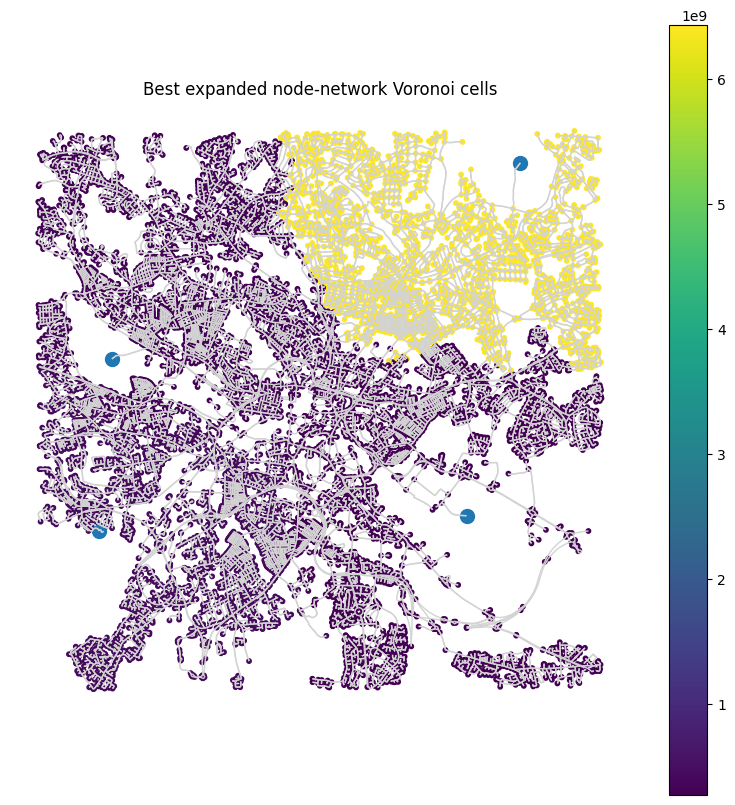

In [39]:
# =========================
# Task C-14: Plot Voronoi cells for best expanded area
# =========================

# ---- plot base road network ----
ax = best_run["edges"].plot(figsize=(10, 10), linewidth=1, color="lightgrey")

# ---- overlay Voronoi cells and seed nodes ----
best_run["node_cells"].plot(
    ax=ax,
    column="seed_id",
    markersize=10,
    legend=True
)

best_run["seed_nodes"].plot(ax=ax, markersize=100)

ax.set_title("Best expanded node-network Voronoi cells")
ax.set_axis_off()
plt.show()

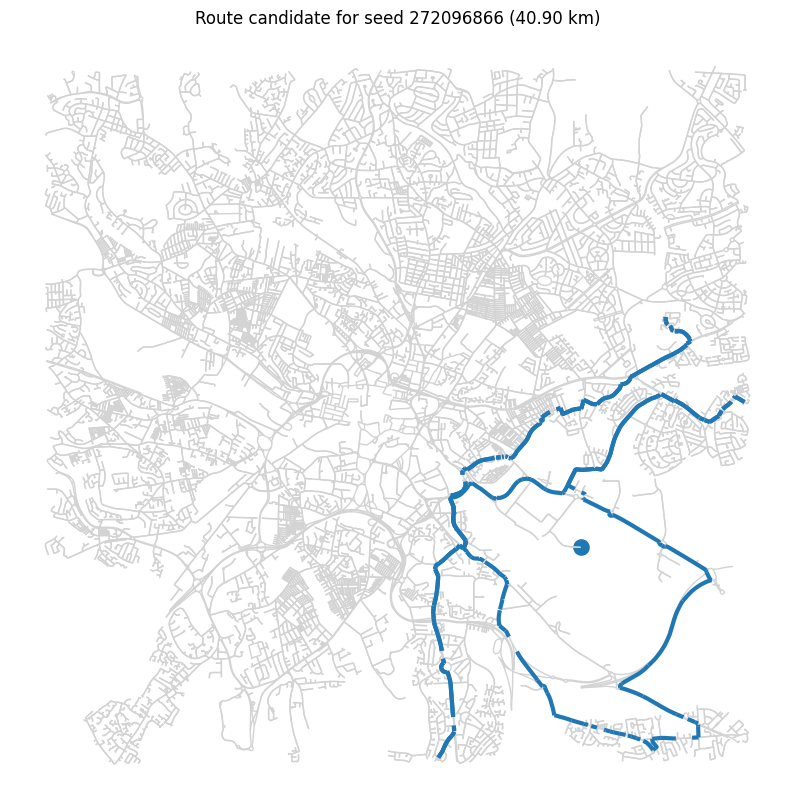

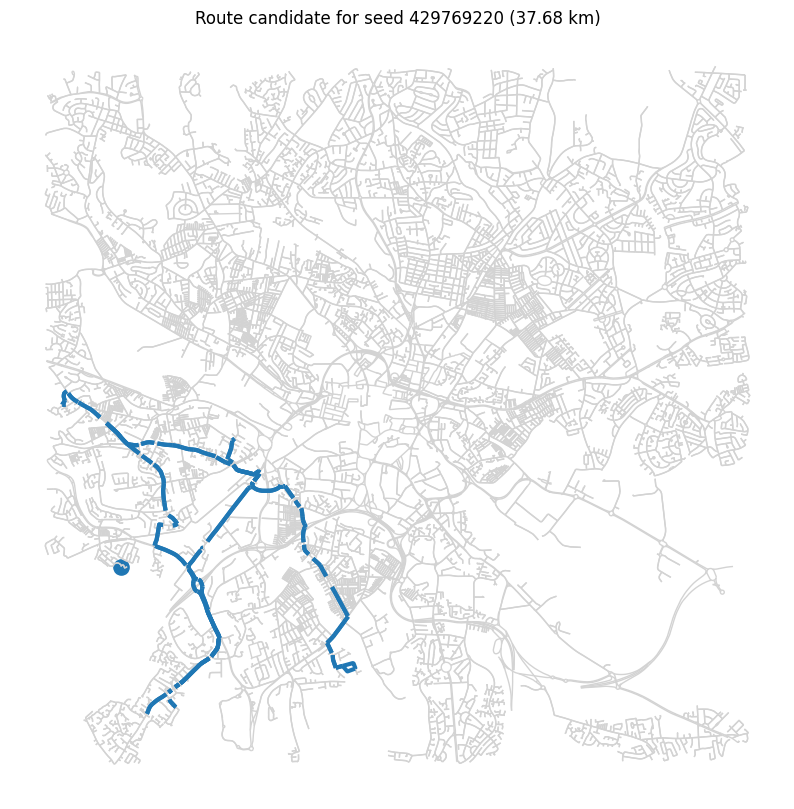

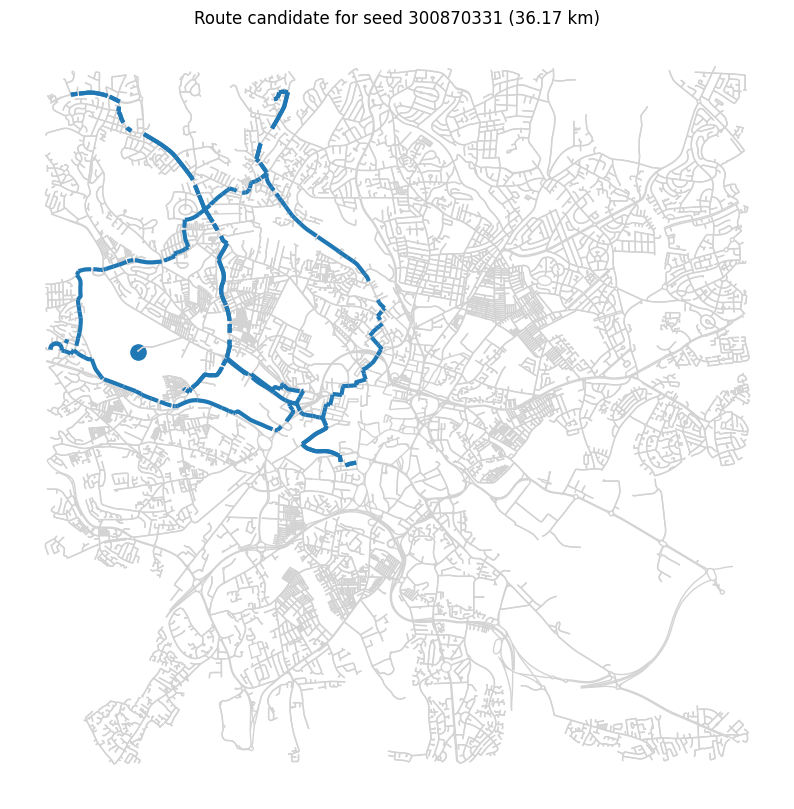

In [40]:
# =========================
# Task C-15: Plot 2 or 3 best marathon route candidates
# =========================

# ---- select the best route candidates ----
successful_routes_df = best_run["results_df"].dropna(subset=["diff_from_42km_m"]).sort_values("diff_from_42km_m")
top_route_seed_ids = successful_routes_df["seed_id"].head(3).tolist()

# ---- plot each selected route candidate ----
for sid in top_route_seed_ids:
    route_nodes, route_length = best_run["routes"][sid]
    route_gdf = route_to_gdf(best_run["G_proj"], route_nodes, crs=best_run["edges"].crs)

    ax = best_run["edges"].plot(figsize=(10, 10), linewidth=1, color="lightgrey")
    route_gdf.plot(ax=ax, linewidth=3)

    best_run["seed_nodes"][best_run["seed_nodes"].index == sid].plot(ax=ax, markersize=120)

    # ---- format and display plot ----
    ax.set_title(f"Route candidate for seed {sid} ({route_length/1000:.2f} km)")
    ax.set_axis_off()
    plt.show()